# BBL Win Probability Model
**Ball-by-ball win probability for the Big Bash League, 2011/12 - 2025/26**

Trained on 647 Cricsheet match files. The model estimates the probability that the
batting side goes on to win, given the state of the match after each delivery, and
uses that to measure which deliveries actually decided a match.

Approach:
- Parse Cricsheet JSON into one row per delivery
- Engineer match-state features: rate, efficiency, pressure, and target context
- Chronological three-way split so the test set is genuinely the future
- XGBoost classifier, evaluated on calibration and Brier score as well as accuracy
- Leverage analysis: win probability change per ball, to rank decisive passages

## 1. Setup

In [1]:
import json
import os
import sys

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, brier_score_loss)
from sklearn.calibration import calibration_curve

sys.path.append('../src')
from features import fit_par_table, build_features, FEATURES, CATEGORICAL, check_finite
from leverage import (compute_leverage, match_summary,
                      leverage_by_over, leverage_by_bowler)

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)

JSON_FOLDER = "../data/cricsheet_jsons/"
MIN_BALLS = 30                                  # predict from over 5 onwards
TRAIN_CUTOFF = pd.to_datetime('2023-12-31')     # train/test boundary
VAL_CUTOFF = pd.to_datetime('2022-06-30')       # fit/validation boundary

NAVY, RED, GREY, GRID, TEXT = "#003087", "#C8102E", "#9AA5B1", "#EDEFF2", "#4A5568"

json_files = sorted(f for f in os.listdir(JSON_FOLDER) if f.endswith('.json'))
print(f"JSON files found: {len(json_files)}")

JSON files found: 662


## 2. Cricsheet structure

Each file is one match. The nesting runs `innings -> overs -> deliveries`, with match
metadata in `info`. Wickets appear as a `wickets` list on the delivery where they fall,
so a delivery with no dismissal simply has no `wickets` key.

In [2]:
with open(os.path.join(JSON_FOLDER, json_files[0])) as f:
    sample = json.load(f)

print("Top level:", list(sample.keys()))
print("Innings:", len(sample['innings']))
print("Batting first:", sample['innings'][0]['team'])
print("Outcome:", sample['info']['outcome'])
print("\nExample delivery:")
print(sample['innings'][0]['overs'][0]['deliveries'][0])

Top level: ['meta', 'info', 'innings']
Innings: 2
Batting first: Sydney Thunder
Outcome: {'by': {'wickets': 9}, 'winner': 'Sydney Sixers'}

Example delivery:
{'actual_delivery': '0.1', 'batter': 'KR Patterson', 'bowler': "SNJ O'Keefe", 'non_striker': 'RJ Gibson', 'runs': {'batter': 2, 'extras': 0, 'total': 2}}


## 3. Extract match state per delivery

Two details that caused bugs worth recording:

**Match identity comes from the filename.** Deriving it from `match_date` merges
matches - the BBL plays several games on the same day, which produced innings numbers
running 1 to 6 instead of 1 to 2.

**Only legal deliveries increment the ball count.** Wides and no-balls do not consume
a ball. Counting them pushed innings past 120, made `balls_remaining` negative, and
produced an infinite `run_rate_needed` that XGBoost refused to train on. The crash was
the lucky outcome - rows just past the boundary gave a required run rate of -36, which
would have trained silently.

In [3]:
def extract_match_state(match_data, innings_num, match_id):
    """One row per delivery, carrying the running state of the innings."""

    innings = match_data['innings'][innings_num]
    batting_team = innings['team']
    match_winner = match_data['info']['outcome']['winner']

    states = []
    cumulative_runs = 0
    cumulative_wickets = 0
    ball_count = 0

    for over in innings['overs']:
        for delivery in over['deliveries']:
            cumulative_runs += delivery['runs']['total']

            if 'wickets' in delivery:
                cumulative_wickets += len(delivery['wickets'])

            # Wides and no-balls don't consume a legal ball
            extras = delivery.get('extras', {})
            if 'wides' not in extras and 'noballs' not in extras:
                ball_count += 1

            states.append({
                'match_id':           match_id,
                'innings_number':     innings_num + 1,
                'match_date':         match_data['info']['dates'][0],
                'venue':              match_data['info']['venue'],
                'batting_team':       batting_team,
                'batter':             delivery['batter'],
                'bowler':             delivery['bowler'],
                'cumulative_runs':    cumulative_runs,
                'cumulative_wickets': cumulative_wickets,
                'balls_faced':        ball_count,
                'overs_completed':    over['over'],
                'did_team_win':       batting_team == match_winner,
            })

    return states

In [4]:
all_states = []
skipped = 0

for filename in json_files:
    try:
        with open(os.path.join(JSON_FOLDER, filename)) as f:
            match = json.load(f)

        # No-result matches (abandoned, washed out) have no winner, so no label
        if 'winner' not in match['info']['outcome']:
            skipped += 1
            continue

        match_id = filename.replace('.json', '')

        for innings_num in range(len(match['innings'])):
            all_states.extend(extract_match_state(match, innings_num, match_id))

    except Exception as e:
        print(f"Error on {filename}: {e}")
        skipped += 1

df = pd.DataFrame(all_states)
df['match_date'] = pd.to_datetime(df['match_date'])

print(f"Deliveries:      {len(df):,}")
print(f"Matches:         {df['match_id'].nunique()}")
print(f"Skipped files:   {skipped}")
print(f"Innings numbers: {sorted(df['innings_number'].unique())}")
print(f"Max balls faced: {df['balls_faced'].max()}   (must not exceed 120)")
print(f"Date range:      {df['match_date'].min().date()} to {df['match_date'].max().date()}")

Deliveries:      151,331
Matches:         647
Skipped files:   15
Innings numbers: [1, 2]
Max balls faced: 120   (must not exceed 120)
Date range:      2011-12-16 to 2026-01-25


## 4. Features

Engineered in `src/features.py` so training and any future inference call the same
code. Recomputing features separately at serving time is the standard way these
systems fail - not with a crash, but by quietly drifting apart.

Four groups:

- **State** - runs, wickets, balls faced
- **Rate and efficiency** - run rate, runs bought per wicket spent, projected score
- **Pressure** - wicket-loss rate, and `runs_per_ball_ratio` (scoring rate divided by
  wicket-loss rate), which separates a side scoring freely from one scoring fast while
  losing wickets
- **Context** - the reference point, which differs by innings

Context is the part that matters most. A chasing side has a target, so `runs_needed`
and `run_rate_needed` are natural. A setting side has none, so the reference is
`par_score`: the median first-innings score at that venue at that ball number.

**Two leakage paths are closed here.** `target_score` is left NaN for innings 1 -
giving the first-innings side its own eventual total would hand the model the answer
mid-innings. And par scores are fitted on training matches only, then applied to both
splits; computing them across the full dataset would fold test-period information into
training. `fit_par_table` takes training data as an argument, so that protection is
enforced by the API rather than left to memory.

`balls_remaining`, `overs_remaining` and `phase` are computed but excluded from the
model. All three are exact transforms of `balls_faced` and carry no additional
information.

One guard worth noting: `run_rate` divides by `balls_faced.clip(lower=1)`. Because
the extraction creates a row for every delivery but only increments the ball count
on legal ones, an innings opening with a wide produces a row where `balls_faced` is
0 — sending `run_rate`, `projected_final_score` and `runs_per_ball_ratio` to
infinity together. The 30-ball filter had been hiding these rows rather than the
problem being absent.

In [5]:
train_raw = df[df['match_date'] <= TRAIN_CUTOFF]
par_table = fit_par_table(train_raw)

df = build_features(df, par_table)

print(f"Model features ({len(FEATURES)}):")
for f in FEATURES:
    print(f"  {f}")

print()
print(df[['balls_faced', 'cumulative_runs', 'par_score', 'runs_vs_par',
          'runs_needed', 'run_rate_needed']].sample(8, random_state=1))

Model features (17):
  cumulative_runs
  cumulative_wickets
  balls_faced
  wickets_remaining
  run_rate
  runs_per_wicket
  projected_final_score
  wicket_loss_rate
  wicket_pressure
  runs_per_ball_ratio
  efficiency_in_death
  is_chasing
  runs_needed
  run_rate_needed
  runs_vs_par
  batting_team
  venue

        balls_faced  cumulative_runs  par_score  runs_vs_par  runs_needed  run_rate_needed
66833            29               39       38.0          1.0         87.0         5.736264
140451           14               18       17.0          1.0          0.0         0.000000
28419            38               49       47.0          2.0         75.0         5.487805
122257           79              113       96.0         17.0         43.0         6.292683
4124             63               74       79.5         -5.5          0.0         0.000000
22543            70               94       89.0          5.0          0.0         0.000000
14205            84               98      106.0     

## 5. Chronological split

Three slices, each genuinely the future relative to the one before:

- **Fit** - 2011 to mid-2022. The model trains here.
- **Validation** - mid-2022 to end 2023. Early stopping watches this.
- **Test** - 2024 onwards. Touched once, at the end.

The validation slice exists to keep early stopping away from the test set. Watching
test loss to decide how many trees to build would let the test set influence a
modelling decision, which quietly inflates the final score.

Deliveries before ball 30 are dropped from training. A prediction two balls in
carries almost no information and pulls the model toward noise — filtering lifted
accuracy from 0.635 to 0.652 and AUC from 0.702 to 0.718.

The training filter and the prediction floor are separate decisions, tested
in section 5a.

In [6]:
model_df = df[df['balls_faced'] >= MIN_BALLS].copy()

train_df = model_df[model_df['match_date'] <= TRAIN_CUTOFF].copy()
test_df  = model_df[model_df['match_date'] >  TRAIN_CUTOFF].copy()

print(f"Train: {len(train_df):,} states, {train_df['match_id'].nunique()} matches "
      f"({train_df['match_date'].min().date()} to {train_df['match_date'].max().date()})")
print(f"Test:  {len(test_df):,} states, {test_df['match_id'].nunique()} matches "
      f"({test_df['match_date'].min().date()} to {test_df['match_date'].max().date()})")
print(f"\nTrain win rate: {train_df['did_team_win'].mean():.2%}")
print(f"Test win rate:  {test_df['did_team_win'].mean():.2%}")

Train: 94,054 states, 541 matches (2011-12-16 to 2023-12-31)
Test:  18,344 states, 106 matches (2024-01-01 to 2026-01-25)

Train win rate: 49.07%
Test win rate:  48.38%


### 5a. Should the second innings start earlier?

The 30-ball floor is well justified for a side batting first: with no target and
`runs_vs_par` near zero, there is genuinely nothing to predict from. It is harder
to justify for a chase, where the target is known from the first delivery and
`run_rate_needed` carries real signal immediately.

Comparing thresholds needs care. Lowering it adds rows to both training and test,
so a lower threshold is judged on harder questions and could score worse while
being a better model. Two evaluations instead of one:

- **`auc_common`** — all models scored on the same rows (innings 2 from ball 30),
  asking whether early training rows help or hurt the states already trusted
- **`auc_early`** — each model scored only on early-chase rows, held fixed across
  all four runs

**Result:** `auc_early` is flat across every threshold (0.750–0.761). Training on
early-chase rows does not improve prediction there. A model that never saw a
delivery before ball 30 of a chase still scores 0.756 on them — it generalises
without being told.

Meanwhile `auc_common` falls monotonically as those rows are added, 0.8181 down to
0.8131. Small, but consistent across all four runs.

**Conclusion: keep the training filter at 30, drop the prediction floor for
chases.** These were being treated as one decision when they are two. The model
handles early-chase states at 0.756 AUC against 0.818 elsewhere — usable, and
measurably less certain.

In [7]:
INN1_MIN = 30   # first innings: keep the existing floor

def build_split(inn2_min):
    """Asymmetric filter — innings 2 can start earlier because the target is known."""
    m = df[((df['innings_number'] == 1) & (df['balls_faced'] >= INN1_MIN)) |
           ((df['innings_number'] == 2) & (df['balls_faced'] >= inn2_min))].copy()
    return m[m['match_date'] <= TRAIN_CUTOFF], m[m['match_date'] > TRAIN_CUTOFF]


def encode(X_tr, X_te):
    X_tr, X_te = X_tr.copy(), X_te.copy()
    for col in CATEGORICAL:
        lookup = {v: i for i, v in enumerate(sorted(X_tr[col].astype(str).unique()))}
        X_tr[col] = X_tr[col].astype(str).map(lookup).astype(int)
        X_te[col] = X_te[col].astype(str).map(lookup).fillna(-1).astype(int)
    return X_tr, X_te


# Early-chase rows from the test period — the states the app cares about
early = df[(df['match_date'] > TRAIN_CUTOFF) &
           (df['innings_number'] == 2) &
           (df['balls_faced'] < 30)]

results = []
for inn2_min in [0, 6, 12, 30]:
    tr, te = build_split(inn2_min)

    fit = tr[tr['match_date'] <= VAL_CUTOFF]
    val = tr[tr['match_date'] > VAL_CUTOFF]

    X_fit, X_val = encode(fit[FEATURES], val[FEATURES])
    _,     X_te  = encode(fit[FEATURES], te[FEATURES])
    _,     X_early = encode(fit[FEATURES], early[FEATURES])

    m = xgb.XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.03,
                          subsample=0.8, colsample_bytree=0.8,
                          min_child_weight=20, reg_lambda=5.0,
                          eval_metric='logloss', early_stopping_rounds=40,
                          random_state=42)
    m.fit(X_fit, fit['did_team_win'].astype(int),
          eval_set=[(X_val, val['did_team_win'].astype(int))], verbose=False)

    # A — common test set, so all thresholds answer the same questions
    common_mask = (te['innings_number'] == 1) | (te['balls_faced'] >= 30)
    auc_common = roc_auc_score(te.loc[common_mask, 'did_team_win'].astype(int),
                               m.predict_proba(X_te[common_mask.values])[:, 1])

    # B — early-chase rows only
    auc_early = roc_auc_score(early['did_team_win'].astype(int),
                              m.predict_proba(X_early)[:, 1])

    results.append({'inn2_min': inn2_min, 'train_rows': len(tr),
                    'best_iter': m.best_iteration,
                    'auc_common': round(auc_common, 4),
                    'auc_early': round(auc_early, 4)})

print(pd.DataFrame(results).to_string(index=False))

 inn2_min  train_rows  best_iter  auc_common  auc_early
        0      110339        162      0.8131     0.7507
        6      107485        175      0.8143     0.7496
       12      104084        143      0.8144     0.7613
       30       94054        164      0.8181     0.7563


## 6. Encode and assemble

Encoders are fitted on training data only. Venues or teams unseen in training map to
-1 rather than causing the transform to fail.

In [8]:
encoders = {}

X_train = train_df[FEATURES].copy()
X_test  = test_df[FEATURES].copy()

for col in CATEGORICAL:
    le = LabelEncoder().fit(X_train[col].astype(str))
    lookup = {label: idx for idx, label in enumerate(le.classes_)}
    X_train[col] = X_train[col].astype(str).map(lookup).astype(int)
    X_test[col]  = X_test[col].astype(str).map(lookup).fillna(-1).astype(int)
    encoders[col] = lookup

y_train = train_df['did_team_win'].astype(int)
y_test  = test_df['did_team_win'].astype(int)

numeric = [c for c in FEATURES if c not in CATEGORICAL]
check_finite(X_train[numeric], "X_train")
check_finite(X_test[numeric], "X_test")

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print(f"Unseen categories in test: "
      f"{int((X_test[CATEGORICAL] == -1).any(axis=1).sum())} rows")

X_train: (94054, 17)   X_test: (18344, 17)
Unseen categories in test: 0 rows


## 7. Train

The first version used 300 trees at depth 6 with no complexity penalty and memorised:
fit accuracy 0.883 against test 0.727, a 15-point gap.

The settings below constrain it. Shallower trees force broader patterns;
`min_child_weight=20` blocks splits built around a handful of rows; `reg_lambda`
penalises complexity; early stopping halts when validation loss stops improving.

The gap fell to 6 points while test accuracy held and AUC *rose* - the sign that what
was removed was noise rather than signal.

In [9]:
fit_mask = train_df['match_date'] <= VAL_CUTOFF
val_mask = ~fit_mask

X_fit, y_fit = X_train[fit_mask.values], y_train[fit_mask.values]
X_val, y_val = X_train[val_mask.values], y_train[val_mask.values]

print(f"Fit: {len(X_fit):,}   Val: {len(X_val):,}   Test: {len(X_test):,}")

model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    reg_lambda=5.0,
    eval_metric='logloss',
    early_stopping_rounds=40,
    random_state=42,
)

model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
print("Best iteration:", model.best_iteration)

fit_proba  = model.predict_proba(X_fit)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= 0.5).astype(int)

print("\nFIT")
print(f"  Accuracy: {accuracy_score(y_fit, (fit_proba >= 0.5).astype(int)):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_fit, fit_proba):.4f}")
print("\nTEST")
print(f"  Accuracy: {accuracy_score(y_test, test_pred):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_test, test_proba):.4f}")
print()
print(classification_report(y_test, test_pred, target_names=['Lost', 'Won']))

Fit: 80,648   Val: 13,406   Test: 18,344


Best iteration: 164

FIT
  Accuracy: 0.7867
  ROC-AUC:  0.8821

TEST
  Accuracy: 0.7309
  ROC-AUC:  0.8181

              precision    recall  f1-score   support

        Lost       0.75      0.72      0.73      9469
         Won       0.71      0.74      0.73      8875

    accuracy                           0.73     18344
   macro avg       0.73      0.73      0.73     18344
weighted avg       0.73      0.73      0.73     18344



## 8. Calibration

The model outputs a probability, not a verdict. Accuracy only checks which side of 0.5
a prediction fell on, so it is blind to whether the number itself is honest - a model
can be 73% accurate while claiming 85% in situations that are really 60%.

Calibration sorts predictions into confidence bands and checks what actually happened
in each. Brier score is the same idea as one number: mean squared distance between
predicted probability and outcome, against a baseline of always predicting the average
win rate.

Before regularisation the 0.83 band won only 64% of the time - a 19-point overstatement
in exactly the range a coach would act on. Fixing the overfitting fixed the
overconfidence, because a memorising model has seen its training patterns resolve
cleanly and pushes probabilities toward the extremes.

In [10]:
prob_true, prob_pred = calibration_curve(y_test, test_proba,
                                        n_bins=10, strategy='quantile')

calibration = pd.DataFrame({
    'predicted': prob_pred.round(3),
    'actual':    prob_true.round(3),
    'gap':       (prob_pred - prob_true).round(3),
})
print(calibration.to_string(index=False))

print(f"\nBrier score: {brier_score_loss(y_test, test_proba):.4f}")
print(f"Baseline:    {brier_score_loss(y_test, np.full(len(y_test), y_train.mean())):.4f}")

for chasing, label in [(0, 'Setting'), (1, 'Chasing')]:
    m = test_df['is_chasing'].values == chasing
    if m.sum() > 200:
        print(f"{label:9s} Brier: {brier_score_loss(y_test[m], test_proba[m]):.4f}")

 predicted  actual    gap
     0.042   0.045 -0.003
     0.137   0.195 -0.058
     0.254   0.284 -0.030
     0.355   0.353  0.001
     0.453   0.385  0.068
     0.543   0.489  0.054
     0.639   0.593  0.046
     0.747   0.639  0.108
     0.848   0.877 -0.029
     0.938   0.980 -0.042

Brier score: 0.1745
Baseline:    0.2498
Setting   Brier: 0.2209
Chasing   Brier: 0.1223


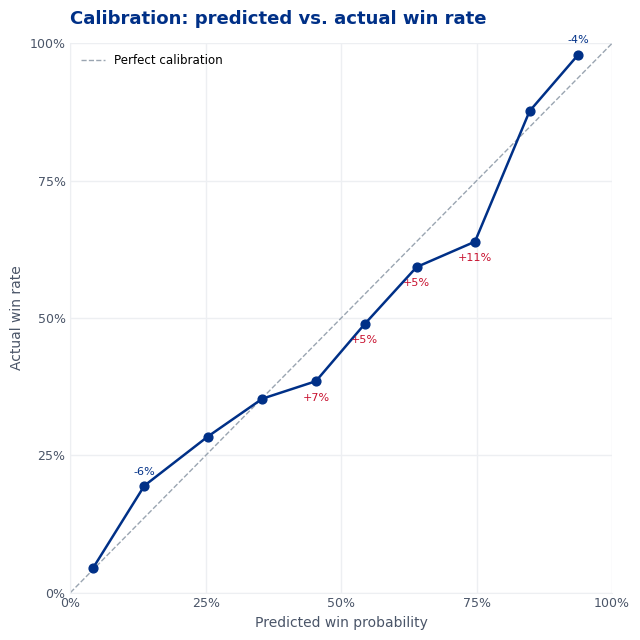

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

ax.plot([0, 1], [0, 1], color=GREY, lw=1, ls='--', zorder=1, label='Perfect calibration')
ax.plot(prob_pred, prob_true, color=NAVY, lw=1.8, zorder=3)
ax.scatter(prob_pred, prob_true, s=40, color=NAVY, zorder=4)

for x, y, gap in zip(prob_pred, prob_true, calibration['gap']):
    if abs(gap) >= 0.04:
        ax.annotate(f'{gap:+.0%}', (x, y), textcoords='offset points',
                   xytext=(0, 8 if gap < 0 else -14), ha='center',
                   fontsize=8, color=RED if gap > 0 else NAVY)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xticks([0, .25, .5, .75, 1]); ax.set_yticks([0, .25, .5, .75, 1])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=9, color=TEXT)
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=9, color=TEXT)
ax.set_xlabel('Predicted win probability', fontsize=10, color=TEXT)
ax.set_ylabel('Actual win rate', fontsize=10, color=TEXT)
ax.grid(color=GRID, lw=1, zorder=0); ax.set_axisbelow(True)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(GRID); ax.spines['bottom'].set_color(GRID)
ax.tick_params(length=0)
ax.legend(loc='upper left', frameon=False, fontsize=8.5)
ax.set_title('Calibration: predicted vs. actual win rate',
             fontsize=13, fontweight='bold', color=NAVY, loc='left', pad=14)

plt.tight_layout()
plt.show()

## 9. Setting versus chasing

The single most useful result in the project, and it is not an accuracy number.

Split by innings, these behave like two different models. Chasing sharpens as the
innings progresses - uncertainty collapses as the target nears. Setting is **flat**: it
does not improve as information accumulates, and its Brier score barely beats a
constant guess.

That is not a modelling failure. For a side batting first, the dominant uncertainty is
the innings that has not been bowled yet. Knowing they finished on 180 says little
until the chase unfolds. The flat line across phases is the evidence that this
uncertainty is irreducible from first-innings data alone.

In [12]:
by_phase = test_df.copy()
by_phase['proba'] = test_proba
by_phase['pred']  = test_pred
by_phase['correct'] = by_phase['pred'] == y_test.values

summary = (by_phase
    .groupby(['is_chasing', 'phase'])
    .apply(lambda g: pd.Series({
        'states':   len(g),
        'accuracy': g['correct'].mean(),
        'roc_auc':  roc_auc_score(g['did_team_win'], g['proba'])
                    if g['did_team_win'].nunique() > 1 else np.nan,
    }), include_groups=False)
    .round(3))

print(summary)

                      states  accuracy  roc_auc
is_chasing phase                               
0          death      3764.0     0.658    0.718
           middle     5186.0     0.642    0.690
           powerplay   758.0     0.616    0.678
1          death      2748.0     0.869    0.962
           middle     5129.0     0.813    0.899
           powerplay   759.0     0.763    0.843


## 10. What drives the prediction

Grouped by feature type. The headline is the split between engineered and raw features:
runs and wickets on their own predict very little, while runs *per wicket*, wickets
*per over*, and runs *against the target or par* carry nearly all the signal.

`is_chasing` scores highly for a binary flag because it acts as a switch rather than a
signal - once a tree splits on it, everything below reads the other features
differently. The model independently arrived at the same conclusion as section 9.

Note that importance measures contribution to the model's splits, not direction. It
cannot say whether a feature pushes predictions up or down.

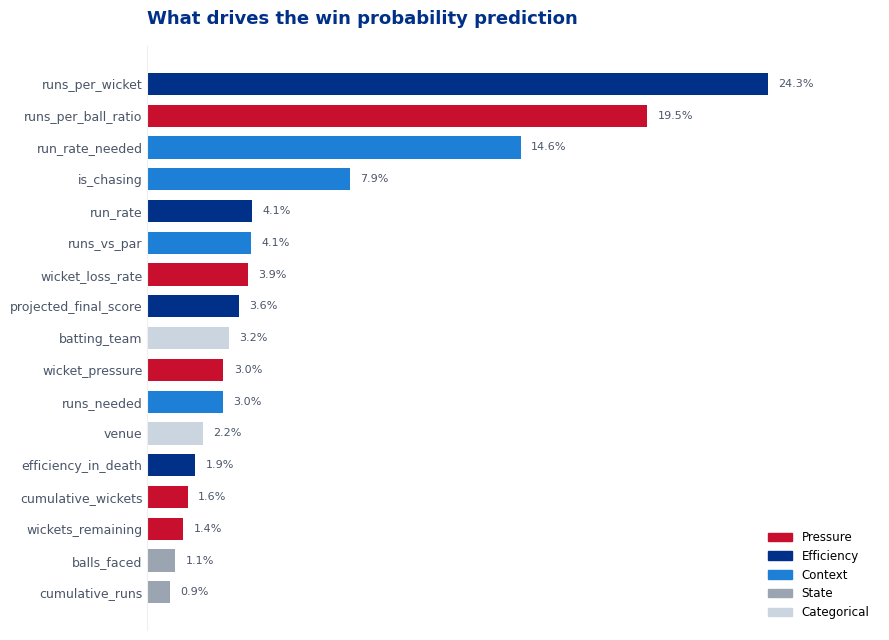

group
Efficiency     0.338
Context        0.295
Pressure       0.294
Categorical    0.053
State          0.020
Name: importance, dtype: float32


In [13]:
GROUPS = {
    'runs_per_ball_ratio': 'Pressure',     'wicket_loss_rate': 'Pressure',
    'wicket_pressure': 'Pressure',         'cumulative_wickets': 'Pressure',
    'wickets_remaining': 'Pressure',
    'runs_per_wicket': 'Efficiency',       'run_rate': 'Efficiency',
    'projected_final_score': 'Efficiency', 'efficiency_in_death': 'Efficiency',
    'runs_needed': 'Context',              'run_rate_needed': 'Context',
    'runs_vs_par': 'Context',              'is_chasing': 'Context',
    'cumulative_runs': 'State',            'balls_faced': 'State',
    'batting_team': 'Categorical',         'venue': 'Categorical',
}
COLORS = {'Pressure': RED, 'Efficiency': NAVY, 'Context': '#1D7FD6',
          'State': GREY, 'Categorical': '#CBD5E0'}

imp = (pd.DataFrame({'feature': X_train.columns,
                     'importance': model.feature_importances_})
       .assign(group=lambda d: d['feature'].map(GROUPS).fillna('State'))
       .sort_values('importance'))

fig, ax = plt.subplots(figsize=(9, 6.5))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

ax.barh(imp['feature'], imp['importance'],
        color=[COLORS[g] for g in imp['group']], height=.7)

for y, v in zip(imp['feature'], imp['importance']):
    if v > 0.005:
        ax.text(v + .004, y, f'{v:.1%}', va='center', fontsize=8, color=TEXT)

ax.set_xlim(0, imp['importance'].max() * 1.18)
ax.tick_params(labelsize=9, colors=TEXT, length=0)
ax.xaxis.set_visible(False)
for s in ('top', 'right', 'bottom'):
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(GRID)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in COLORS.values()]
ax.legend(handles, COLORS.keys(), loc='lower right', frameon=False, fontsize=8.5)

ax.set_title('What drives the win probability prediction',
             fontsize=13, fontweight='bold', color=NAVY, loc='left', pad=16)
plt.tight_layout()
plt.show()

print(imp.groupby('group')['importance'].sum().sort_values(ascending=False).round(3))

## 11. Where it goes wrong

Two failure modes worth watching: confident predictions of a win that lost, where the
model over-reads early momentum, and confident predictions of a loss that won, where it
under-reads a side grinding with wickets down.

In [14]:
errors = by_phase[~by_phase['correct']]
cols = ['balls_faced', 'cumulative_runs', 'cumulative_wickets', 'run_rate',
        'runs_per_wicket', 'runs_needed', 'is_chasing', 'proba']

print(f"Misclassified: {len(errors):,} of {len(by_phase):,} "
      f"({len(errors) / len(by_phase):.1%})\n")

print("Predicted WIN with high confidence, but lost:")
print(errors[(errors['pred'] == 1) & (errors['proba'] > 0.8)][cols]
      .head(8).to_string(index=False))

print("\nPredicted LOSS with high confidence, but won:")
print(errors[(errors['pred'] == 0) & (errors['proba'] < 0.2)][cols]
      .head(8).to_string(index=False))

Misclassified: 4,937 of 18,344 (26.9%)

Predicted WIN with high confidence, but lost:
 balls_faced  cumulative_runs  cumulative_wickets  run_rate  runs_per_wicket  runs_needed  is_chasing    proba
          85              102                   5      7.20        17.000000         30.0           1 0.839619
          86              103                   5      7.19        17.166667         29.0           1 0.843693
          33               47                   0      8.55        47.000000        111.0           1 0.818678
          34               47                   0      8.29        47.000000        111.0           1 0.818678
          34               48                   0      8.47        48.000000        110.0           1 0.819436
          35               48                   0      8.23        48.000000        110.0           1 0.819436
          39               55                   0      8.46        55.000000        103.0           1 0.851607
          40              

## 12. Leverage

The change in win probability between consecutive deliveries measures how much that
ball moved the match. Ranking those changes gives the passages that actually decided
it - measured rather than eyeballed.

Two things make it more than a subtraction, both handled in `src/leverage.py`:

**Perspective.** The model outputs the batting side's probability, and the batting side
changes at the innings break. Everything is flipped to one reference team first,
otherwise the diff across that boundary compares two different quantities.

**The innings-break artifact.** The first version reported a 57% swing on the first ball
of a chase and attributed it to the bowler. Nothing happened on that ball - at the break
the model's framing changes, so the probability re-anchors. That jump is now excluded
from the rankings and reported separately.

In [15]:
# Genuinely close matches: finished within 10 runs of the target.
# Note that margin alone is misleading - a successful chase stops the moment the
# target is passed, so almost every won chase shows a margin of 1 or 2. Depth into
# the innings is what separates a tense finish from a routine one.
last_ball = (by_phase.sort_values('balls_faced')
             .groupby('match_id').tail(1)
             .query('innings_number == 2'))

targets = (by_phase.query('innings_number == 1')
           .groupby('match_id')['cumulative_runs'].max().rename('target'))

fin = last_ball.join(targets, on='match_id')
fin['margin'] = (fin['target'] - fin['cumulative_runs']).abs()

close_matches = (fin[fin['margin'] <= 10]
                 .nlargest(6, 'balls_faced')[['match_id', 'target', 'cumulative_runs',
                                              'cumulative_wickets', 'did_team_win',
                                              'margin']])
print(close_matches.to_string(index=False))

match_id  target  cumulative_runs  cumulative_wickets  did_team_win  margin
 1386131     187              180                   4         False       7
 1493263     127              130                   6          True       3
 1443065     174              175                   7          True       1
 1443072     156              148                   8         False       8
 1386132     197              201                   7          True       4


In [16]:
close_id = close_matches['match_id'].iloc[0]
close_lev = compute_leverage(by_phase[by_phase['match_id'] == close_id])

print(match_summary(close_lev, top_n=8))

death = close_lev[(close_lev.innings_number == 2) & (close_lev.balls_faced >= 96)]
print(f"\nDeath overs swing: {death['leverage'].abs().sum():.3f}")
print(f"wp range:          {death['wp'].min():.2f} to {death['wp'].max():.2f}")

Reference: Hobart Hurricanes   final win probability 92.3%
Innings break re-anchor: +10.6% (model reframing, not attributed to any delivery)

Biggest 8 swings:
  Inn 2  18.5  155/4 CJ Jordan to MP Stoinis WICKET   +17.4%
  Inn 1  18.3  158/5 NM Coulter-Nile to Nikhil Chaudhary WICKET   -13.5%
  Inn 2  16.1  131/3 CJ Jordan to MP Stoinis   -9.7%
  Inn 1  20.2  177/7 Imad Wasim to NT Ellis   +8.8%
  Inn 2  16.4  135/3 CJ Jordan to MP Stoinis   +8.6%
  Inn 2   8.5   68/2 P Hatzoglou to GJ Maxwell   -8.4%
  Inn 2   8.4   64/2 P Hatzoglou to GJ Maxwell   -7.9%
  Inn 2   9.1   73/2 NT Ellis to GJ Maxwell   -7.7%

Death overs swing: 0.359
wp range:          0.75 to 0.96


### Does leverage behave sensibly?

A leverage tool is only useful if it stays quiet when a match is dead and responds when
it is live. Comparing a one-sided match against a close one is the check: total
death-over swing differs by two orders of magnitude between them.

Flat leverage in a blowout is the correct answer, not a limitation.

In [17]:
blowout_id = fin.nlargest(1, 'margin')['match_id'].iloc[0]
blowout_lev = compute_leverage(by_phase[by_phase['match_id'] == blowout_id])

for name, lv in [('Close match', close_lev), ('One-sided match', blowout_lev)]:
    d = lv[(lv.innings_number == 2) & (lv.balls_faced >= 96)]
    print(f"{name:18s} death swing {d['leverage'].abs().sum():.3f}   "
          f"wp range {d['wp'].min():.2f}-{d['wp'].max():.2f}")

Close match        death swing 0.359   wp range 0.75-0.96
One-sided match    death swing 0.039   wp range 0.98-0.99


In [18]:
print("Most expensive overs for the reference team:")
print(leverage_by_over(close_lev).head(6).to_string(index=False))

print("\nBy bowler (wp_saved positive = helped their own side):")
print(leverage_by_bowler(close_lev).to_string(index=False))

Most expensive overs for the reference team:
 innings_number  over     net  swing  runs_end  wickets           bowler
              1    18 -0.1820 0.2226       161        1  NM Coulter-Nile
              1     6 -0.0671 0.0671        48        0  NM Coulter-Nile
              2    17 -0.0567 0.0674       151        0      RP Meredith
              1    15 -0.0544 0.0777       135        1      DW Lawrence
              2     8 -0.0415 0.2850        69        0      P Hatzoglou
              2     6 -0.0405 0.2240        50        0 Nikhil Chaudhary

By bowler (wp_saved positive = helped their own side):
 innings_number           bowler  balls  wp_saved  runs_conceded_swing  wickets  wp_per_ball
              2        CJ Jordan     24   -0.2100               0.6736        1     -0.00875
              2         NT Ellis     21   -0.0892               0.4021        1     -0.00425
              1        SM Boland      8   -0.0741               0.0916        0     -0.00926
              1 

## 13. Win probability through a match

Each innings is drawn as its own line. Connecting them would span the first 30 balls of
the chase, which the model does not predict - the resulting straight segment reads as a
smooth climb through deliveries that were never modelled. Those regions are shaded
instead.

Wicket markers are coloured by who benefits: red when the reference team loses one,
navy when they take one.

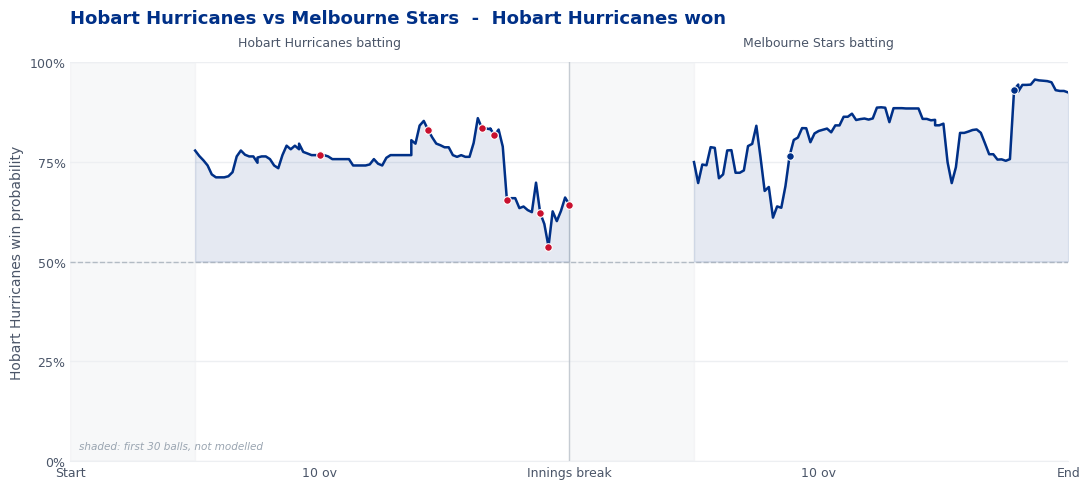

In [19]:
def plot_win_probability(lev, smooth=1, save_path=None):
    """Takes the output of compute_leverage, which has already flipped wp to one
    team's perspective and built a continuous ball index across both innings."""
    m = lev.sort_values("ball_index").copy()
    if smooth > 1:
        m["wp"] = m.groupby("innings_number")["wp"].transform(
            lambda s: s.rolling(smooth, center=True, min_periods=1).mean())

    inn1, inn2 = m[m.innings_number == 1], m[m.innings_number == 2]
    t1, t2 = inn1.batting_team.iloc[0], inn2.batting_team.iloc[0]
    ref = m.attrs.get("reference_team") or t1
    other = t2 if ref == t1 else t1
    won = m.wp.iloc[-1] > 0.5
    start = int(m.balls_faced.min())

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")
    ax.axhline(0.5, color=GREY, lw=1, ls="--", alpha=.7, zorder=2)
    ax.axvline(120, color=GREY, lw=1, alpha=.5, zorder=2)

    for leg in (inn1, inn2):
        ax.fill_between(leg.ball_index, .5, leg.wp, where=leg.wp >= .5,
                        color=NAVY, alpha=.10, zorder=1, interpolate=True)
        ax.fill_between(leg.ball_index, .5, leg.wp, where=leg.wp < .5,
                        color=RED, alpha=.10, zorder=1, interpolate=True)
        ax.plot(leg.ball_index, leg.wp, color=NAVY, lw=1.8, zorder=4)

        w = leg[leg.is_wicket]
        helps_ref = leg.batting_team.iloc[0] != ref
        ax.scatter(w.ball_index, w.wp, s=30, color=NAVY if helps_ref else RED,
                   edgecolors="white", linewidths=.8, zorder=5)

    for x0 in (0, 120):
        ax.axvspan(x0, x0 + start, color=GREY, alpha=.07, zorder=0)

    ax.set_ylim(0, 1); ax.set_xlim(0, 240)
    ax.set_yticks([0, .25, .5, .75, 1])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=9, color=TEXT)
    ax.set_xticks([0, 60, 120, 180, 240])
    ax.set_xticklabels(["Start", "10 ov", "Innings break", "10 ov", "End"],
                       fontsize=9, color=TEXT)
    ax.set_ylabel(f"{ref} win probability", fontsize=10, color=TEXT)
    ax.grid(axis="y", color=GRID, lw=1, zorder=0); ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID); ax.tick_params(length=0)

    ax.text(60, 1.04, f"{t1} batting", ha="center", fontsize=9, color=TEXT)
    ax.text(180, 1.04, f"{t2} batting", ha="center", fontsize=9, color=TEXT)
    ax.text(2, .03, f"shaded: first {start} balls, not modelled",
            fontsize=7.5, color=GREY, style="italic")
    ax.set_title(f"{ref} vs {other}  -  {ref} {'won' if won else 'lost'}",
                 fontsize=13, fontweight="bold", color=NAVY, loc="left", pad=28)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()


plot_win_probability(close_lev)

## 14. Results and limitations

**Test set: 2024-2026, never used for any modelling decision.**

| Metric | Value |
|---|---|
| Accuracy | 0.728 |
| ROC-AUC | 0.816 |
| Brier | 0.175 (baseline 0.250) |
| Fit/test gap | 0.059 |

Chasing (Brier 0.124) is a much stronger model than setting (0.221), for the structural
reason in section 9.

**Limitations, in the order worth addressing:**

- **Prediction scope is asymmetric.** The first innings is only predicted from ball
  30; a chase can be predicted from ball 1, at a measurably lower 0.756 AUC.
- **No player identity.** The model sees 112/2 after 12 overs without knowing whether an
  opener or a number nine is on strike. The largest remaining gap, and the next thing to
  build.
- **Mild mid-range overconfidence.** The calibration table leans roughly +0.05 to +0.10
  through the 0.45-0.75 bands. Left uncorrected deliberately - a small adjustment where
  the model is already hedging does not change its usefulness, and a calibration wrapper
  is more machinery to maintain than the gain justifies.
- **Understatement at the extremes.** The regularisation that fixed overconfidence also
  compressed the model's reach toward certainty. In one-sided matches it settles around
  96-99% and stops moving, which is defensible since flatness is correct there.
- **Static par scores.** Medians across all training seasons, so they do not reflect
  that scoring rates have risen over fifteen years.
- **No hyperparameter search.** Settings are reasoned rather than tuned.

**A pattern worth recording.** Four separate times a plausible-looking filter measured
the wrong thing: grouping on `match_date` merged same-day matches; counting every
delivery broke the ball count; and ranking matches by runs margin returned only
successful chases, because a chase stops the moment the target is passed. Each produced
output that looked reasonable. Checking whether numbers mean what they appear to mean
caught all three.
And the 30-ball filter turned out to be doing two jobs — discarding low-information
rows, which was intended, and hiding malformed ones where an opening wide left
`balls_faced` at 0, which was not. Loosening the filter surfaced a bug that had
been there the whole time.

In [20]:
print(f"Accuracy {accuracy_score(y_test, test_pred):.4f}  AUC {roc_auc_score(y_test, test_proba):.4f}")
print(f"Brier {brier_score_loss(y_test, test_proba):.4f}")
print(imp.groupby('group')['importance'].sum().sort_values(ascending=False).round(3))

Accuracy 0.7309  AUC 0.8181
Brier 0.1745
group
Efficiency     0.338
Context        0.295
Pressure       0.294
Categorical    0.053
State          0.020
Name: importance, dtype: float32


## 15. Saving the artifacts

Everything above lives in kernel memory. `model`, `encoders`, and `par_table` are
Python objects that disappear the moment this notebook stops running - a prediction
service needs them as files it can load at process start, with no dependency on this
notebook ever having executed.

Four pieces, and none of them is useful without the other three:

- **`win_probability_model.joblib`** - the trained XGBoost classifier.
- **`encoders.joblib`** - the `batting_team` / `venue` lookups, fitted on training
  data. A team or venue string means nothing to the model on its own; it means
  whatever integer this exact mapping assigned it during training. A service with
  its own idea of how to encode "Perth Stadium" would feed the model a different
  venue's history.
- **`par_table.joblib`** - the median first-innings score by venue and ball number,
  fitted on training matches only. `runs_vs_par` doesn't exist without it, and
  recomputing par at serving time from whatever data is on hand then is exactly the
  leakage `fit_par_table` was built to prevent in section 4 - it would fold
  post-training matches into a feature the model never saw computed that way.
- **`metadata.json`** - `FEATURES` in column order, the two cutoff dates, the
  asymmetric ball floor from section 5a, the tree count early stopping actually
  settled on, and the test-set numbers this exact combination produced. Not needed
  to compute a prediction, but needed to tell, months from now, whether a service
  still loading these four files is still describing the model this notebook
  trained.

The model alone can't read a team name without the encoders, can't place a score
against its baseline without the par table, and carries no record of what order its
own inputs belong in without the metadata. Splitting these into separate files - as
opposed to one big pickle of "the model" - keeps that dependency explicit rather than
buried inside an opaque blob.

In [21]:
import joblib

MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(model, f"{MODELS_DIR}/win_probability_model.joblib")
joblib.dump(encoders, f"{MODELS_DIR}/encoders.joblib")
joblib.dump(par_table, f"{MODELS_DIR}/par_table.joblib")

metadata = {
    "features": FEATURES,
    "train_cutoff": str(TRAIN_CUTOFF.date()),
    "val_cutoff": str(VAL_CUTOFF.date()),
    # Ball floor used to build the training rows above (section 5).
    "training_filter": {
        "innings_1_min_ball": MIN_BALLS,
        "innings_2_min_ball": MIN_BALLS,
    },
    # Floor recommended at serving time - chases predicted from ball 1 (section 5a).
    "prediction_floor": {
        "innings_1_min_ball": MIN_BALLS,
        "innings_2_min_ball": 1,
    },
    "best_iteration": int(model.best_iteration),
    "test_metrics": {
        "accuracy": round(float(accuracy_score(y_test, test_pred)), 4),
        "roc_auc": round(float(roc_auc_score(y_test, test_proba)), 4),
        "brier": round(float(brier_score_loss(y_test, test_proba)), 4),
        "early_chase_auc": round(float(
            next(r["auc_early"] for r in results if r["inn2_min"] == 30)
        ), 4),
    },
}

with open(f"{MODELS_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved to {os.path.abspath(MODELS_DIR)}:")
for fn in sorted(os.listdir(MODELS_DIR)):
    print(" ", fn)

Saved to /Users/kushgirap/Desktop/bbl-win-probability/models:
  encoders.joblib
  metadata.json
  par_table.joblib
  win_probability_model.joblib


### Does the round trip preserve predictions?

The four files are only as good as their agreement with each other. Loading them
back, rebuilding a feature matrix from raw match state through the ordinary
`build_features` pipeline, and predicting should reproduce `test_proba` exactly - not
approximately. Anything short of exact means the saved par table, encoders, or
feature order disagree with what actually trained the model, which is precisely the
silent-drift failure mode this section exists to catch before a service does.

In [22]:
loaded_model    = joblib.load(f"{MODELS_DIR}/win_probability_model.joblib")
loaded_encoders = joblib.load(f"{MODELS_DIR}/encoders.joblib")
loaded_par      = joblib.load(f"{MODELS_DIR}/par_table.joblib")
with open(f"{MODELS_DIR}/metadata.json") as f:
    loaded_meta = json.load(f)

# Rebuild from raw state only - the same inputs a prediction service would have,
# run through the same feature pipeline, against the artifacts just loaded from disk.
raw_cols = ["match_id", "innings_number", "balls_faced", "batting_team", "venue",
            "cumulative_runs", "cumulative_wickets", "overs_completed"]
rebuilt = build_features(df[raw_cols], loaded_par)

sample_idx = test_df.head(100).index
X_sample = rebuilt.loc[sample_idx, loaded_meta["features"]].copy()
for col in CATEGORICAL:
    X_sample[col] = (X_sample[col].astype(str)
                     .map(loaded_encoders[col]).fillna(-1).astype(int))

loaded_proba = loaded_model.predict_proba(X_sample)[:, 1]
target_proba = test_proba[:100]

max_diff = np.abs(loaded_proba - target_proba).max()
assert max_diff < 1e-9, f"Round trip mismatch: max diff {max_diff:.2e}"

print(f"Round trip verified on {len(X_sample)} rows loaded straight from disk.")
print(f"Max absolute difference from test_proba: {max_diff:.2e}")

Round trip verified on 100 rows loaded straight from disk.
Max absolute difference from test_proba: 0.00e+00
